# Script for visualising spectra

This notebook includes code to visualize identified spectra from MaxQuant. 

In [16]:
import pandas as pd 
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import ScalarFormatter
import os
import numpy as np
import re
from adjustText import adjust_text
from collections import defaultdict
from tqdm import tqdm

plt.rcParams["font.family"] = "Arial" 

In [17]:
def get_color(match):
    first_letter = match[0]
    if first_letter == 'y':
        return 'red'
    elif first_letter == 'b':
        return 'blue'
    elif first_letter == 'd':
        return 'pink'
    else:
        return 'black'

In [23]:
alp_folder = 'PATH_TO_FOLDER_WITH_.apl'

# used to fetch the identification annotations
file = "PATH_TO/msms.txt"

In [19]:
df = pd.read_csv(file, delimiter="\t")

# reading MS data from apl files

In [12]:
def read_apl(FOLDER):
    """Function to parse apl files. Written by Martin Rykær + Caroline Lennartsson"""

    outer_dict = defaultdict(dict)
    intens_dict = defaultdict(dict)
    
    print('Reading apl files')
    
    apl_files = [os.path.join(FOLDER, file) for file in os.listdir(FOLDER) if file.endswith(".apl") and not 'secpep' in file] 

    for apl_file in tqdm(apl_files):
        with open(apl_file, 'r') as f:
            for l in f.readlines():
                if l == 'peaklist start\n':
                    #row = {}
                    mass_list, intens  = [], []
                elif l[:2] == 'mz':
                    ms1 = float(l[3:].strip())
                elif l[:13] == 'fragmentation':
                    fragm = l[14:].strip()
                elif l[:6] == 'charge':
                    charge = int(l[7:].strip())
                elif l[:6] == 'header':
                    x = l.split(' ')
                    raw_file = x[1]
                    index = int(x[3])
                elif l == 'peaklist end\n':
                    outer_dict[raw_file][index] = mass_list 
                    intens_dict[raw_file][index] = intens 
                elif l == '\n':
                    continue
                else:
                    mass, intensity = [x.strip() for x in l.split('\t')]
                    mass_list.append(float(mass))
                    intens.append(float(intensity)) 
    
    return outer_dict, intens_dict 

In [13]:
outer_dict, intens_dict = read_apl(alp_folder)

Reading apl files


100%|███████████████████████████████████████████| 96/96 [00:03<00:00, 29.89it/s]


In [67]:
def plot_spectrum_with_matches(df, outer_dict, intens_dict, scan_number):
    row = df[df['Scan number'] == scan_number]
    row = row.iloc[0]
    matches = row['Matches']
    masses = [float(x) for x in row['Masses'].split(';')]
    match_intensities = [float(x) for x in row['Intensities'].split(';')]
    mz_values = outer_dict[row['Raw file']][scan_number]
    intensities = intens_dict[row['Raw file']][scan_number]

    print(scan_number) 
    print(row['Sequence'])

    fig, ax = plt.subplots(figsize=(8, 3))

    for mz, intensity in zip(mz_values, intensities):
        ax.plot([mz, mz], [0, intensity], color='grey', linestyle='-')

    for match, mass, intensity in zip(matches.split(';'), masses, match_intensities):
        ax.plot([mass, mass], [0, intensity], color=get_color(match), linestyle='-', alpha=1)
    
    texts = [
         ax.text(mass, intensity, match, ha='center', va='bottom', fontsize=7)
         for match, mass, intensity in zip(matches.split(';'), masses, match_intensities)
    ]
    adjust_text(texts, expand=(1.1, 1.5), arrowprops=dict(arrowstyle='->', color='black'))

        
    elif pions == 3: 
        # Only plot matches that are -p2, -p3, or p-7
        selected_matches = []
        selected_masses = []
        selected_intensities = []
        
        for match, mass, intensity in zip(matches.split(';'), masses, match_intensities):
            if any(p in match for p in ['-p2', '-p3', '-p7']) or 'p' not in match:
                selected_matches.append(match)
                selected_masses.append(mass)
                selected_intensities.append(intensity)
        
        for match, mass, intensity in zip(selected_matches, selected_masses, selected_intensities):
            ax.plot([mass, mass], [0, intensity], color=get_color(match), linestyle='-', alpha=1)
            
        texts = [
             ax.text(mass, intensity, match, ha='center', va='bottom', fontsize=7)
             for match, mass, intensity in zip(selected_matches, selected_masses, selected_intensities)
        ]
        adjust_text(texts, expand=(1.1, 1.5), arrowprops=dict(arrowstyle='->', color='black'))
    
    elif pions == 0: 
        # Plot everything EXCEPT matches containing 'p' (no p ions)
        selected_matches = []
        selected_masses = []
        selected_intensities = []
        
        for match, mass, intensity in zip(matches.split(';'), masses, match_intensities):
            if 'p' not in match:
                selected_matches.append(match)
                selected_masses.append(mass)
                selected_intensities.append(intensity)
        
        for match, mass, intensity in zip(selected_matches, selected_masses, selected_intensities):
            ax.plot([mass, mass], [0, intensity], color=get_color(match), linestyle='-', alpha=1)
            
        texts = [
             ax.text(mass, intensity, match, ha='center', va='bottom', fontsize=7)
             for match, mass, intensity in zip(selected_matches, selected_masses, selected_intensities)
        ]
        adjust_text(texts, expand=(1.1, 1.5), arrowprops=dict(arrowstyle='->', color='black'))

    ax.set_xlabel('m/z')
    ax.set_ylabel('Intensity')
    all_intensities = intensities + match_intensities
    ax.set_ylim(0, 1.2 * max(all_intensities))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    plt.tight_layout()

    plt.savefig(f"{fig_dir}/{scan_number}_{row['Sequence']}_{pions}_spectra.pdf", transparent=True)

    plt.show()

16993
DGQVVLIKQEK


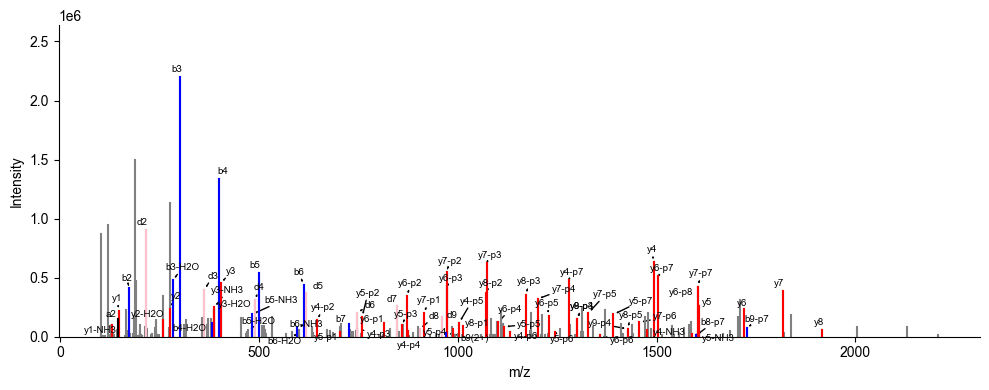

16993
DGQVVLIKQEK


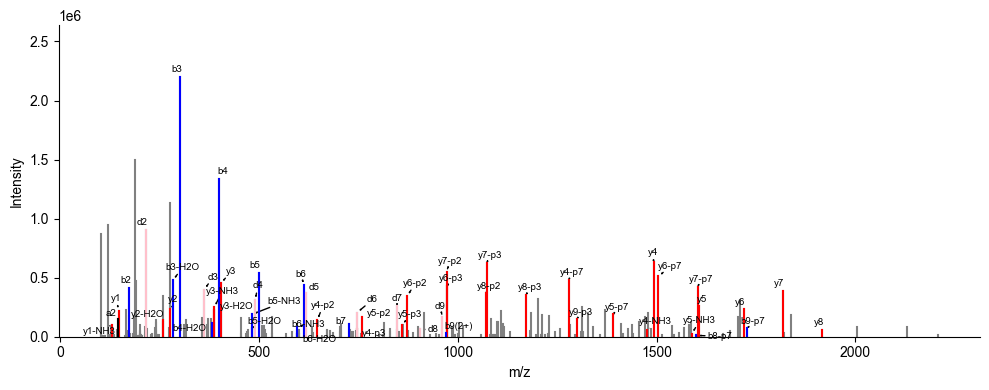

16993
DGQVVLIKQEK


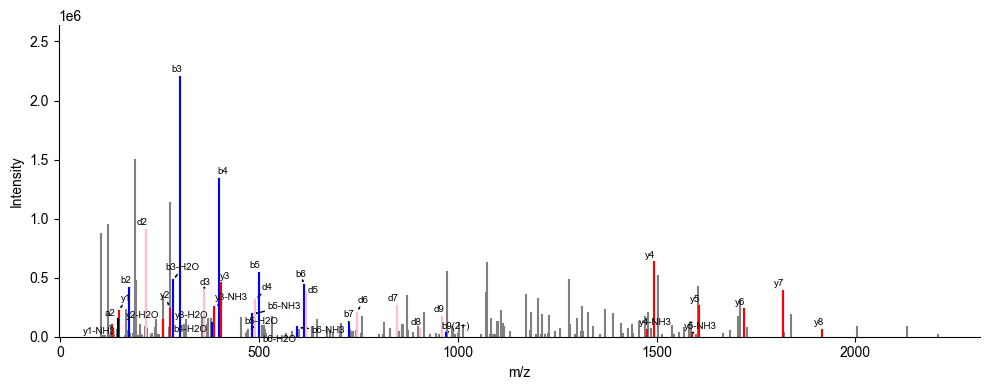

In [65]:
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=16993)
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=16993, pions = 3)
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=16993, pions = 0)

26205
DIIVLQRGGTGFAGSGVKLQAEK


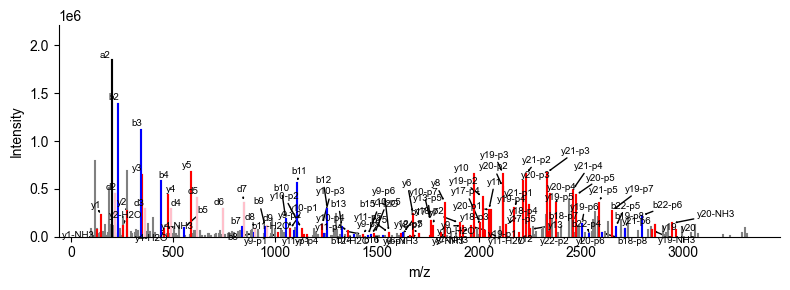

26205
DIIVLQRGGTGFAGSGVKLQAEK


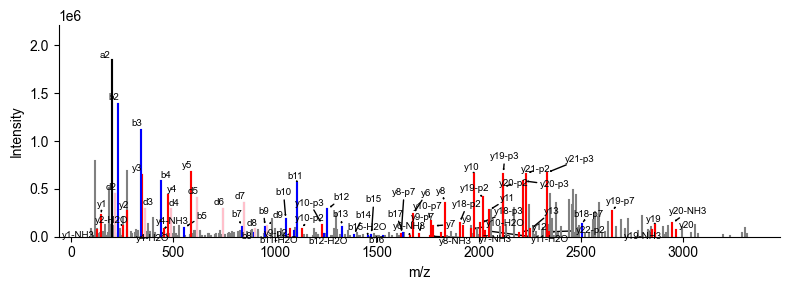

26205
DIIVLQRGGTGFAGSGVKLQAEK


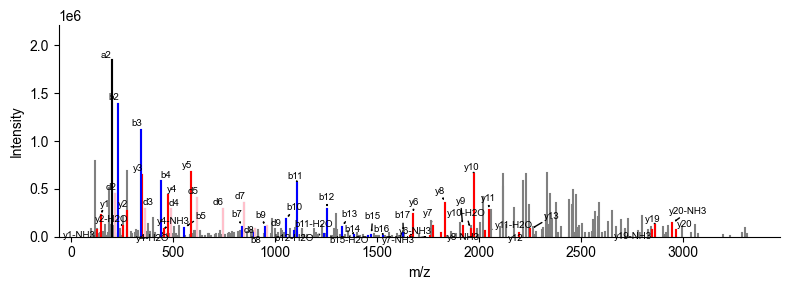

In [68]:
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=26205)
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=26205, pions = 3)
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=26205, pions = 0)

27006
ESIGSELGNSFASNIRIKE


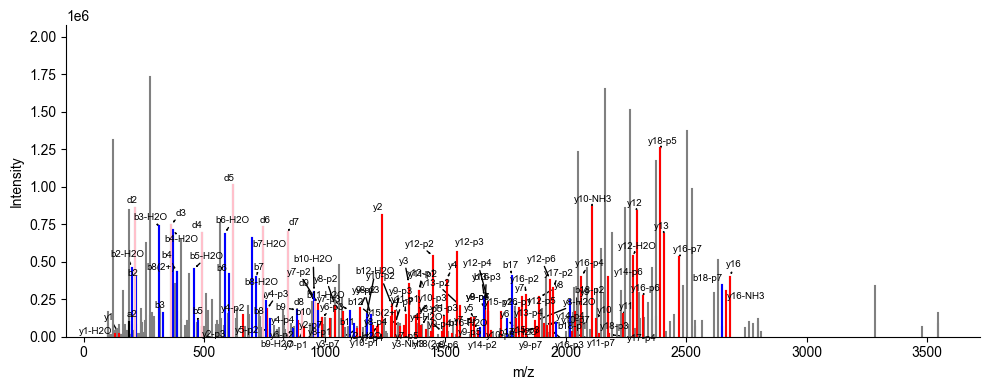

27006
ESIGSELGNSFASNIRIKE


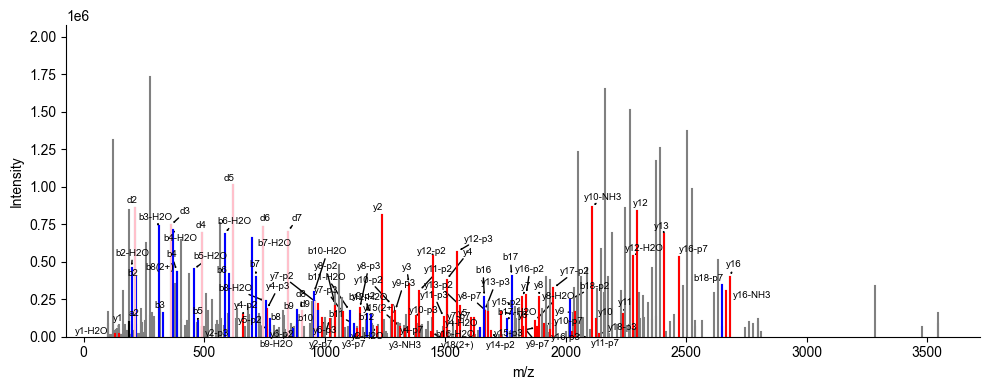

27006
ESIGSELGNSFASNIRIKE


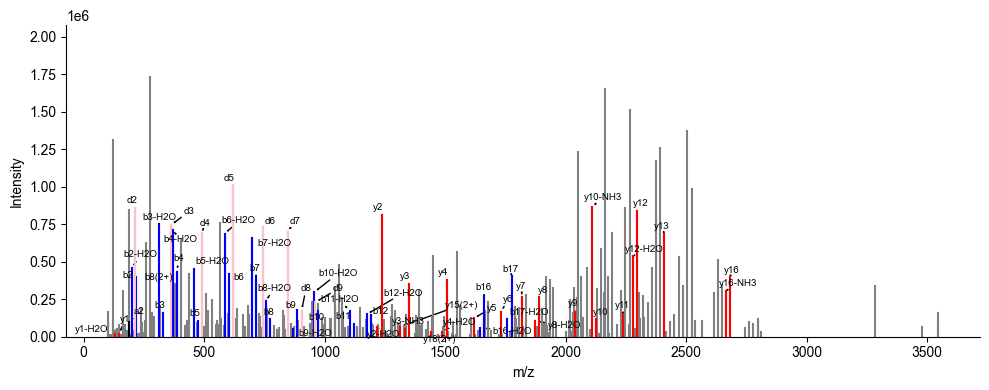

In [63]:
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=27006)
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=27006, pions = 3)
plot_spectrum_with_matches(sumo_sel, outer_dict, intens_dict, scan_number=27006, pions = 0)